# **Aerofit Treadmill Buyer Analysis**

A self-guided project to practice my EDA, SQL and data analytics / science skills.

## **Objective**

The market research team at AeroFit wants to identify the characteristics of the target audience for each type of treadmill offered by the company, to provide a better recommendation of the treadmills to new customers. The team decides to investigate whether there are differences across the product with respect to customer characteristics.
1.   Perform descriptive analytics to create a item customer profile for each AeroFit treadmill product by developing appropriate tables and charts.
2.   For each AeroFit treadmill product, construct two-way contingency tables and compute all conditional and marginal probabilities along with their insights/impact on the business.




## **Approach**

I intend to approach this by exploring the data, initially writing some basic SQL queries followed by a more rigorous data inspection using Python. Based on the insights I uncover, I will present my findings and business recommendations.

## **Exploratory Data Analysis (EDA)**

I first examined the csv file by importing the data into MySQL Workbench and wrote SQL queries to retrieve some basic data. Refer to the file on the GitHub repo: [*aerofit_sql.sql*](https://github.com/vish-mandalika/treadmill-buyer-analysis/blob/main/aerofit_sql.sql)

This notebook will now document the EDA process using Python to examine the Aerofit Treadmill buyer profile.

In [4]:
# Import statements
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [5]:
# Loading the data and printing the first few rows
raw_data = pd.read_csv('aerofit_treadmill_data.csv')

In [6]:
# Printing summary statistics and checking for missing values
print('First 5 rows of data')
print(raw_data.head())
print('\n')
print('Data types')
print(raw_data.dtypes)
print('\n')
print('No. of null values per variable:')
print(raw_data.isnull().sum())
print('\n')
print('Summary statistics:')
print(raw_data.describe())

First 5 rows of data
  Product  Age  Gender  Education MaritalStatus  Usage  Fitness  Income  Miles
0   KP281   18    Male         14        Single      3        4   29562    112
1   KP281   19    Male         15        Single      2        3   31836     75
2   KP281   19  Female         14     Partnered      4        3   30699     66
3   KP281   19    Male         12        Single      3        3   32973     85
4   KP281   20    Male         13     Partnered      4        2   35247     47


Data types
Product          object
Age               int64
Gender           object
Education         int64
MaritalStatus    object
Usage             int64
Fitness           int64
Income            int64
Miles             int64
dtype: object


No. of null values per variable:
Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64


Summary statistics:
              Age   E

### **Descriptive Analytics by Product**

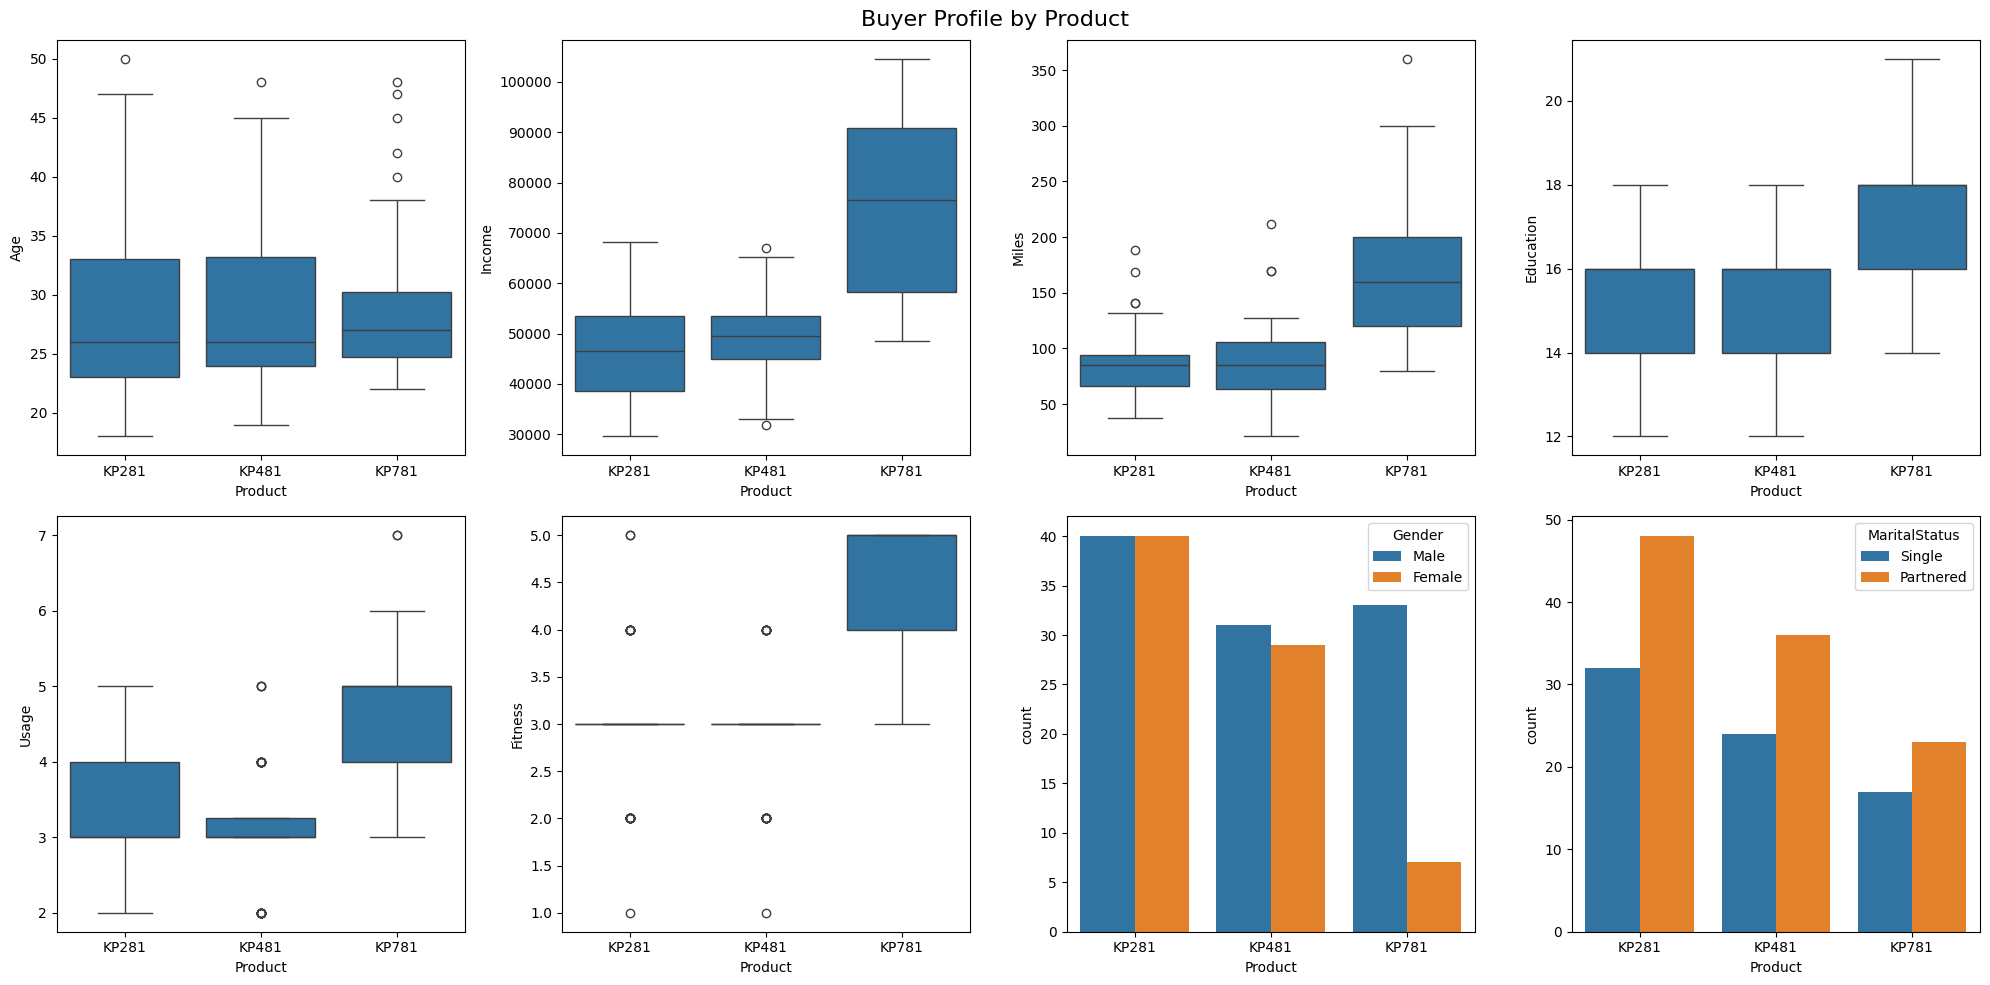

In [7]:
# Boxplots for Age, Education, Income, and Miles by Product
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Buyer Profile by Product', fontsize=16)

sns.boxplot(data=raw_data, x='Product', y='Age', ax=axes[0, 0])
sns.boxplot(data=raw_data, x='Product', y='Income', ax=axes[0, 1])
sns.boxplot(data=raw_data, x='Product', y='Miles', ax=axes[0, 2])
sns.boxplot(data=raw_data, x='Product', y='Education', ax=axes[0, 3])

# Usage, Fitness, Gender and Marital Status vs Product type
sns.boxplot(data=raw_data, x='Product', y='Usage', ax=axes[1, 0])
sns.boxplot(data=raw_data, x='Product', y='Fitness', ax=axes[1, 1])
sns.countplot(data=raw_data, x='Product', hue='Gender', ax=axes[1, 2])
sns.countplot(data=raw_data, x='Product', hue='MaritalStatus', ax=axes[1, 3])

plt.tight_layout()
plt.show()

We can see that the median age is approximately the same across all treadmills on offer indicating age is not significantly driving the selection of a particular type of treadmill. We can however see that the purchasers of KP781 tend to have a higher median income (~$77k) and this makes sense as this model is the most expensive. In support of this, the count plot of Education by product type also shows that buyers who purchase KP781 tend to have more years in education than for the other models. These two observations go hand-in-hand as people who have spent more time in education tend to have a higher income.

In terms of Gender distributions, KP281 and KP481 are approximately even between male and female buyers, however KP781 is dominated by male buyers. Marital Status on the other hand does not seem to play a significant role or tell us a story about how it is related to the product type being chosen.

The most important takeaway from this initial glance, is that the Fitness level (middle 50% between level 4 and 5), Usage (middle 50% plans to use it 4-5 times/week) and Miles (middle 50% plans to get 125-200 miles of usage) for KP781 are significantly higher than the other groups. Furthemore, the KP781 is the least purchased out of the three product types. This indicates that the buyers who are purchasing KP781, are "power-users" who care about maximizing the use of Aerofit's top-of-the-line treadmill. Aerofit could consider altering their marketing approach to push this treadmill model to the athletes or those who are passionate about their cardiovascular training.

### **KDE plots - Age, Income, Miles by Product**

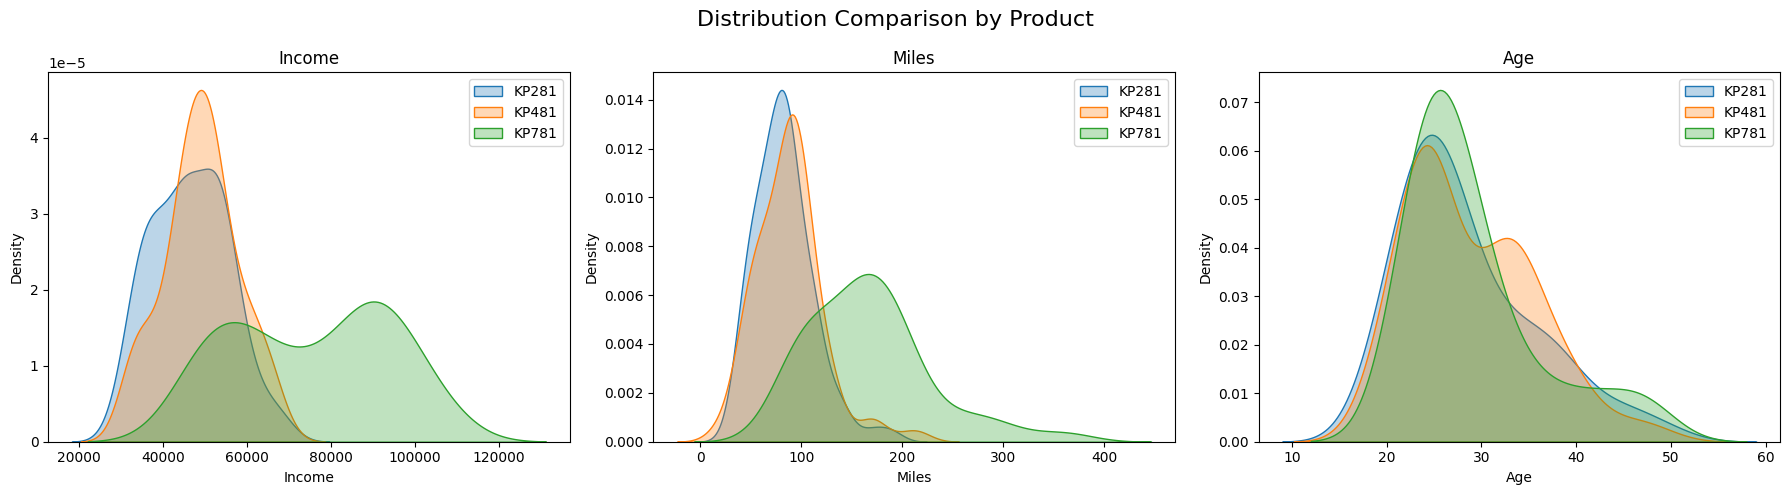

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution Comparison by Product', fontsize=16)

for col, ax in zip(['Income', 'Miles', 'Age'], axes):
    for product in raw_data['Product'].unique():
        sns.kdeplot(data=raw_data[raw_data['Product'] == product],
                    x=col, label=product, ax=ax, fill=True, alpha=0.3)
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

###**Correlation heatmaps for numerical variables**

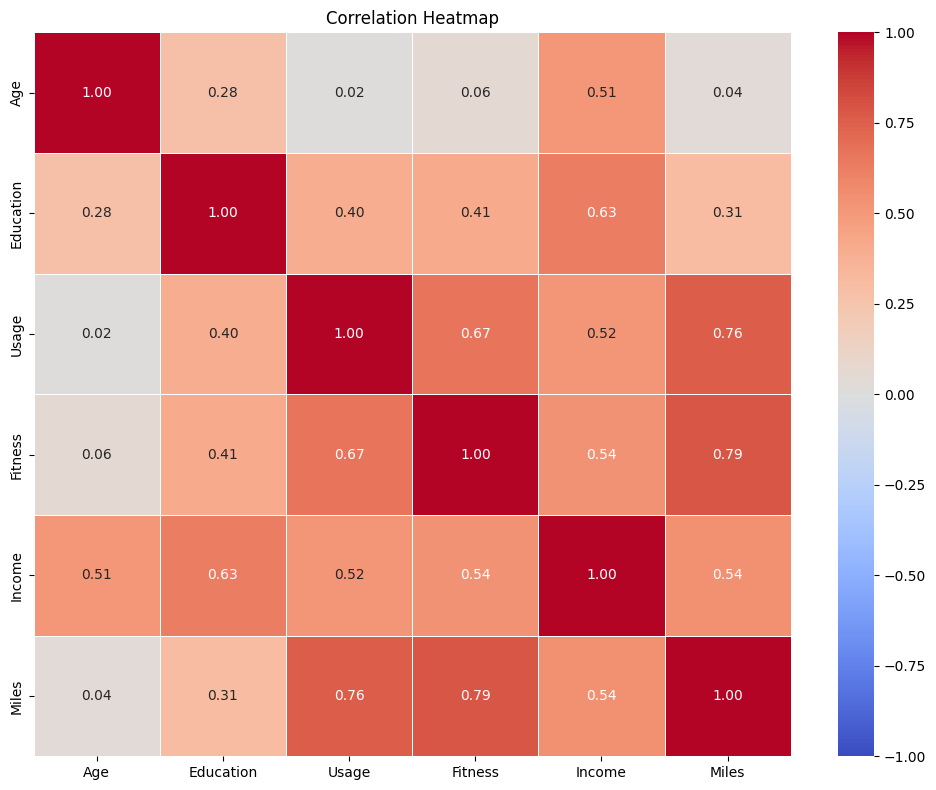

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(raw_data.select_dtypes(include='number').corr(),
            annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

The strongest correlations from the heatmap above are Miles-Fitness (0.79), Miles-Usage (0.76) and Usage-Fitness (0.67). The correlation coefficients tell us that these three variables move together. Essentially, people who perceive themselves as more fit also plan to use the treadmill more often and expect to cover more miles. These could represent the athlete or passionate runner profile that gravitates towards the KP781.

As I previously pointed out, Income-Education (0.63) is strong but expected as more education typically means higher earnings. Income-Age (0.51) also makes sense since older buyers have had more time to grow their income.

The main point from this heatmap which reinforces my understanding of the initial glance is that Age has almost no correlation with Usage (0.02), Fitness (0.06) and Miles (0.04). Therefore, age does not predict how intensely someone uses the treadmill. The insight here is that Aerofit treadmills do not need to be specifically targeted at "older, wealthier" customers rather they should focus on pitching it towards "high-fitness, high-usage" customers regardless of age.

---


*Note: This is the overall correlation across all treadmill types combined. These relationships may look different within each product group which are unreliable but covered below.*

**Note: The following heatmaps are not reliable due to the 40-80 limited sample size. This exposes the correlation coefficients to be heavily impacted by outliers in the data. I am just plotting these for my own learning and inspection.**

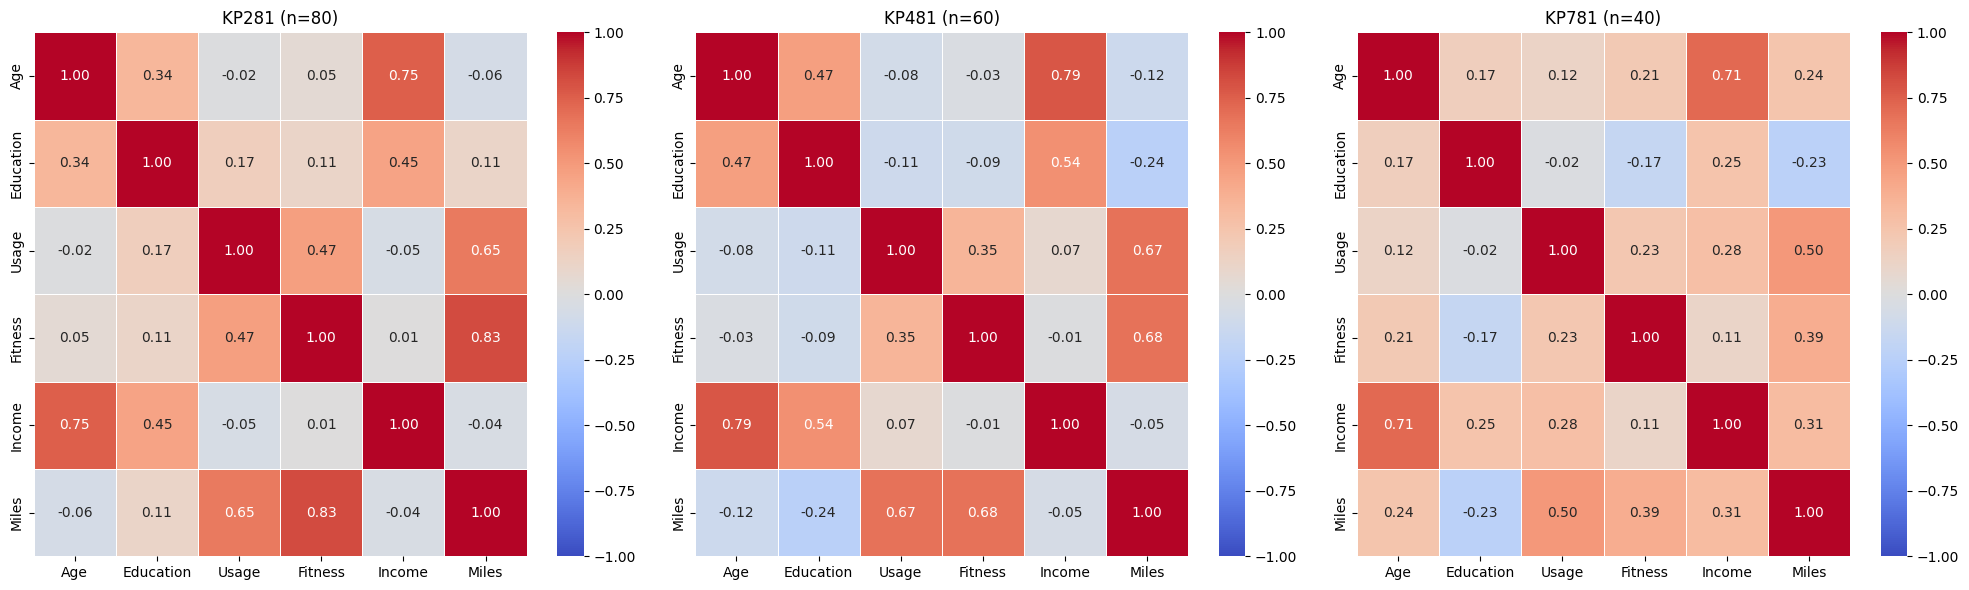

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, product in zip(axes, raw_data['Product'].unique()):
    subset = raw_data[raw_data['Product'] == product].select_dtypes(include='number')
    sns.heatmap(subset.corr(), annot=True, cmap='coolwarm', fmt='.2f',
                linewidths=0.5, vmin=-1, vmax=1, ax=ax)
    ax.set_title(f'{product} (n={len(subset)})')

plt.tight_layout()
plt.show()

### **Contingency tables**

The table below is just to understand the distribution of male and female customers for each treadmill type.

In [12]:
# Raw counts
ct_gender = pd.crosstab(raw_data['Product'], raw_data['Gender'], margins=True)
print(ct_gender)

Gender   Female  Male  All
Product                   
KP281        40    40   80
KP481        29    31   60
KP781         7    33   40
All          76   104  180


The table below shows us that given the buyer's gender, what is the probability of them purchasing a particular type of treadmill. We can see that 31.7% of male customers purchased the KP781. Therefore, if a male walks into the store, there is roughly 1/3 chance he is interested in the KP781. For females, this chance drops to approximately 1/10 for the same product type.

In [13]:
# Conditional probability: P(Product | Gender)
# "Given someone is Male, what's the probability they bought each product?"
ct_product_gender = pd.crosstab(raw_data['Product'], raw_data['Gender'], normalize='columns')
print(ct_product_gender)

Gender     Female      Male
Product                    
KP281    0.526316  0.384615
KP481    0.381579  0.298077
KP781    0.092105  0.317308


The table below is useful for the marketing team to understand who their current KP781 customer base actually is. 82.5% of the KP781 (premium) buyers are male. The gender distribution for the other two types is approximately the same.

In [14]:
# Conditional probability: P(Gender | Product)
# "Given someone bought KP781, what's the probability they are Male?"
ct_gender_product = pd.crosstab(raw_data['Product'], raw_data['Gender'], normalize='index')
print(ct_gender_product)


Gender     Female      Male
Product                    
KP281    0.500000  0.500000
KP481    0.483333  0.516667
KP781    0.175000  0.825000


From the earlier EDA, we observed a lack of a significant relationship between Marital Status and the type of treadmill purchased. This is further reinforced by the values in the contingency table. Hence, knowing someone's marital status does not help predict which treadmill they are going to buy.

In [15]:
# Conditional probability: P(MaritalStatus | Product)
# "Of KP781 buyers, what fraction are Married vs Single?"
ct_marital_product = pd.crosstab(raw_data['Product'], raw_data['MaritalStatus'], normalize='index')
print(ct_marital_product)

MaritalStatus  Partnered  Single
Product                         
KP281              0.600   0.400
KP481              0.600   0.400
KP781              0.575   0.425


Checking the other direction shows that the distribution is nearly identical for married and single customers, roughly 44/33/23% for KP281/KP481/KP781 regardless of marital status. This confirms from the other direction that marital status is not a useful predictor.

In [16]:
# Conditional probability: P(Product | MaritalStatus)
# "If someone is partnered, what's the probability they bought KP781?"
ct_product_marital = pd.crosstab(raw_data['MaritalStatus'], raw_data['Product'], normalize='index')
print(ct_product_marital)

Product           KP281     KP481     KP781
MaritalStatus                              
Partnered      0.448598  0.336449  0.214953
Single         0.438356  0.328767  0.232877


The table below provides an interesting insight and re-affirms my understanding from the initial EDA. 72.5% of the KP781 buyers rate themselves to be a fitness level 5, while 67.5% of KP281 buyers rate themselves at fitness level 3. The distribution for KP281 and KP481 are almost identical. Ultimately, this table re-affirms that the fitness level is probably the single strongest indicator of which treadmill type someone buys.

In [17]:
# Conditional probability: P(Fitness | Product)
# "Given someone bought KP781, what's the Fitness level distribution?"
ct_fitness_product = pd.crosstab(raw_data['Product'], raw_data['Fitness'], normalize='index')
print(ct_fitness_product)

Fitness         1      2      3         4      5
Product                                         
KP281    0.012500  0.175  0.675  0.112500  0.025
KP481    0.016667  0.200  0.650  0.133333  0.000
KP781    0.000000  0.000  0.100  0.175000  0.725


## **Recommendations**


### **KP281**

This is the entry-level Aerofit treadmill priced at \$1500. The buyer profile consists of a balanced gender split, averaging an income around $46k-48k, rating themselves at fitness level 3, planning to get about 3 sessions per week and moderate mileage. This group reflects "casual fitness" buyers who want a basic treadmill for general health.

### **KP481**

This is the mid-tier Aerofit treadmill priced at \$1750. The buyer profile is very similar to the KP281 in terms of fitness and demographics although with a slightly higher income. Since the buyer behavior overlaps heavily with KP281, it suggests the product differentiation between these two is not very strong from a customer perspective.

### **KP781**

This is the premium model priced at $2500. The buyer profile is heavily dominated by males (82.5%) with a higher average income (\$75k+), rating themselves at fitness level 5, planning to get about 4-6 sessions per week and significantly higher mileage. This group reflects "serious runners" who want an advanced treadmill for the best performance.

Based on the analysis of the data, my key recommendations to the team at Aerofit are:


1.   Consider marketing KP781 to female fitness enthusiasts as they are underserved for this product type. Brand deals with female fitness social media influencers may drive more female buyers to the premium product.

2.   The overlap between the KP281 and KP481 buyer profile suggests an opportunity to differentiate through features or targeted messaging. For example, the KP481 could be specifically targeted at those who want to improve their fitness from level 3 to 4-5. This positions this product above the "entry-level" model and as a stepping stone towards the "serious runner" segment.

3.   KP781 buyers are clearly goal-oriented. Aerofit can further capitalize on this by offering a premium membership for fitness tracking/coaching or app integration with performance metrics. This would reinforce their purchase decision and justify the price premium.

4.   The contingency tables showed that fitness level and usage intent are the lead drivers behind the treadmill purchased. Aerofit sales staff should be asking questions in store such as "how often do you plan to run?" and "What is your current fitness routine?" rather than making assumptions based on demographics.

5.   KP781 has the lowest sales volume with 40/180 purchases. The team needs to understand whether this is due to price sensitivity, lack of awareness/marketing or just a genuinely smaller target market. Further study into this aspect may allow Aerofit to expand the sales volume of their premium line and generate more revenue.


